In [4]:
df = con.execute("""
    SELECT *
    FROM analytics.model_features
""").df()

df.head()

,time,temperature_2m_max,precipitation_sum,wind_speed_10m_max,relative_humidity_2m_mean,cloud_cover_mean,apparent_temperature_max,sunshine_duration,city,month,day_of_month,temperature_lag_1,precipitation_lag_1,wind_lag_1,humidity_lag_1,temperature_3d_avg,precipitation_7d_sum,wind_3d_avg,humidity_7d_avg,city_encoded
0,2020-01-02,8.6,0.0,33.0,88,50,3.2,30162.88,Baku,1,2,11.4,0.0,11.4,90.0,10.000000,0.0,22.200000,89.000000,0
1,2020-01-03,7.6,1.7,24.1,83,96,3.3,1147.69,Baku,1,3,8.6,0.0,33.0,88.0,9.200000,1.7,22.833333,87.000000,0
2,2020-01-04,8.4,0.2,22.7,83,98,4.6,1300.71,Baku,1,4,7.6,1.7,24.1,83.0,8.200000,1.9,26.600000,86.000000,0
3,2020-01-05,7.7,2.6,12.6,91,100,6.4,0.00,Baku,1,5,8.4,0.2,22.7,83.0,7.900000,4.5,19.800000,87.000000,0
4,2020-01-06,9.8,0.0,9.5,91,65,7.7,30867.98,Baku,1,6,7.7,2.6,12.6,91.0,8.633333,4.5,14.933333,87.666667,0


In [10]:
#df["month"] = pd.to_datetime(df["date"]).dt.month

df_may_june = df[df["month"].isin([5, 6])]

In [12]:
df_may_june

,time,temperature_2m_max,precipitation_sum,wind_speed_10m_max,relative_humidity_2m_mean,cloud_cover_mean,apparent_temperature_max,sunshine_duration,city,month,day_of_month,temperature_lag_1,precipitation_lag_1,wind_lag_1,humidity_lag_1,temperature_3d_avg,precipitation_7d_sum,wind_3d_avg,humidity_7d_avg,city_encoded
120,2020-05-01,19.5,0.0,20.2,78,24,18.5,46341.87,Baku,5,1,18.0,0.0,23.0,77.0,18.366667,3.5,21.866667,75.714286,0
121,2020-05-02,19.6,0.0,20.7,83,45,19.0,43993.52,Baku,5,2,19.5,0.0,20.2,78.0,19.033333,0.0,21.300000,77.000000,0
122,2020-05-03,22.9,1.3,14.9,81,52,26.2,44030.64,Baku,5,3,19.6,0.0,20.7,83.0,20.666667,1.3,18.600000,77.285714,0
123,2020-05-04,22.5,0.0,23.3,76,43,22.3,46191.04,Baku,5,4,22.9,1.3,14.9,81.0,21.666667,1.3,19.633333,77.000000,0
124,2020-05-05,25.8,0.0,21.6,62,85,24.7,33037.54,Baku,5,5,22.5,0.0,23.3,76.0,23.733333,1.3,19.933333,74.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10766,2025-06-26,29.3,0.0,7.4,58,2,30.9,50400.00,Shaki,6,26,27.0,0.0,13.5,56.0,27.100000,7.5,13.933333,62.857143,4
10767,2025-06-27,30.5,0.0,13.9,53,0,31.1,50400.00,Shaki,6,27,29.3,0.0,7.4,58.0,28.933333,7.5,11.600000,62.857143,4
10768,2025-06-28,30.8,0.0,14.8,46,14,30.9,48684.55,Shaki,6,28,30.5,0.0,13.9,53.0,30.200000,6.3,12.033333,60.857143,4
10769,2025-06-29,29.1,1.4,15.9,53,40,30.8,48426.45,Shaki,6,29,30.8,0.0,14.8,46.0,30.133333,1.7,14.866667,56.714286,4


In [16]:
df.shape
df.info()

df["time"].min(), df["time"].max()
df["city"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10955 entries, 0 to 10954
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   time                       10955 non-null  datetime64[ns]
 1   temperature_2m_max         10955 non-null  float64       
 2   precipitation_sum          10955 non-null  float64       
 3   wind_speed_10m_max         10955 non-null  float64       
 4   relative_humidity_2m_mean  10955 non-null  int64         
 5   cloud_cover_mean           10955 non-null  int64         
 6   apparent_temperature_max   10955 non-null  float64       
 7   sunshine_duration          10955 non-null  float64       
 8   city                       10955 non-null  object        
 9   month                      10955 non-null  int32         
 10  day_of_month               10955 non-null  int32         
 11  temperature_lag_1          10955 non-null  float64       
 12  prec

city
Baku        2191
Gabala      2191
Guba        2191
Lankaran    2191
Shaki       2191
Name: count, dtype: int64

In [18]:
target_cols = [
    "temperature_2m_max",
    "precipitation_sum",
    "wind_speed_10m_max",
    "relative_humidity_2m_mean",
    "cloud_cover_mean"
]

df.groupby("city")[target_cols].describe()

temperature_2m_max                                                \
                      count       mean        std   min   25%   50%   75%   
city                                                                        
Baku                 2191.0  19.571794   9.315995  -1.0  11.2  19.2  27.6   
Gabala               2191.0  21.975399  10.298094   0.1  12.9  21.8  31.2   
Guba                 2191.0  16.363578  10.101184 -10.4   8.1  16.5  24.8   
Lankaran             2191.0  19.349338   8.081841  -0.1  12.2  19.1  26.6   
Shaki                2191.0  19.437335   9.462976  -1.4  11.4  19.5  27.5   

               precipitation_sum            ... relative_humidity_2m_mean  \
           max             count      mean  ...                       75%   
city                                        ...                             
Baku      40.0            2191.0  0.838247  ...                      81.0   
Gabala    42.4            2191.0  1.010269  ...                      78.0   
Guba      39.0            2191.0  1.709265  ...                      82.0   
Lankaran  36.5            2191.0  2.669785  ...                      85.0   
Shaki     38.5            2191.0  2.057736  ...                      79.0   

               cloud_cover_mean                                               \
           max            count       mean        std  min   25%   50%   75%   
city                                                                           
Baku      97.0           2191.0  48.070744  34.175133  0.0  16.0  46.0  80.0   
Gabala    98.0           2191.0  45.014149  31.546737  0.0  17.0  43.0  71.0   
Guba      99.0           2191.0  55.609767  33.388138  0.0  26.0  58.0  88.0   
Lankaran  99.0           2191.0  52.529895  35.189648  0.0  19.0  52.0  88.0   
Shaki     99.0           2191.0  47.878138  31.924558  0.0  20.0  45.0  75.5   

                 
            max  
city             
Baku      100.0  
Gabala    100.0  
Guba      100.0  
Lankaran  100.0  
Shaki     100.0  

[5 rows x 40 columns]

# 4. Trends and city comparison

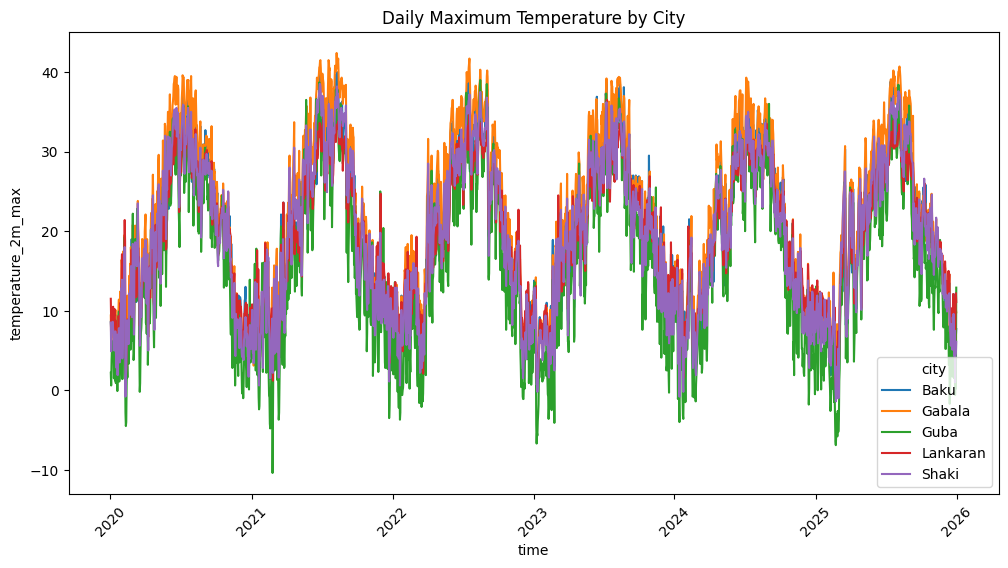

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.lineplot(data=df, x="time", y="temperature_2m_max", hue="city")
plt.title("Daily Maximum Temperature by City")
plt.xticks(rotation=45)
plt.show()

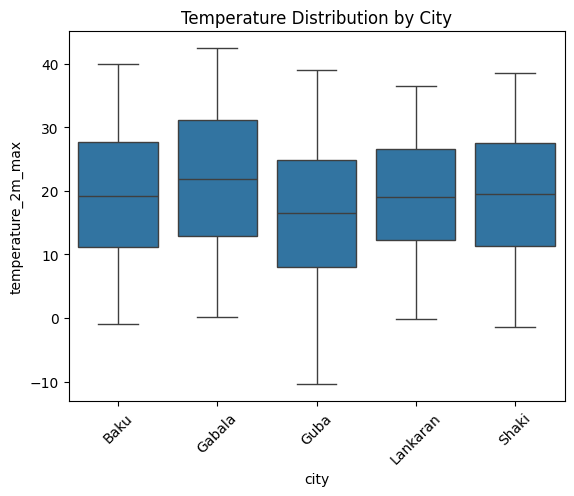

In [24]:
sns.boxplot(data=df, x="city", y="temperature_2m_max")
plt.title("Temperature Distribution by City")
plt.xticks(rotation=45)
plt.show()

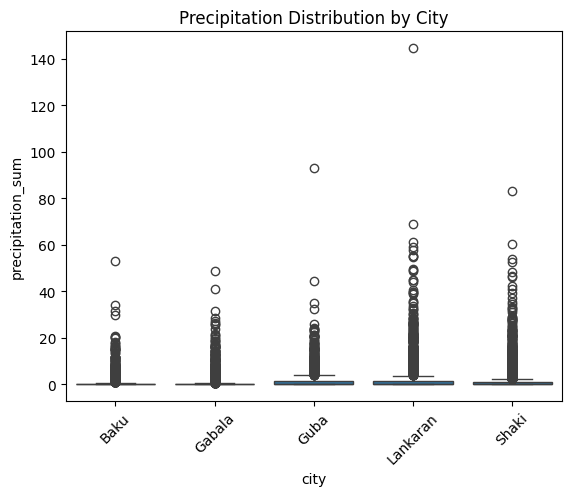

In [26]:
sns.boxplot(data=df, x="city", y="precipitation_sum")
plt.title("Precipitation Distribution by City")
plt.xticks(rotation=45)
plt.show()

## Correlation Analys

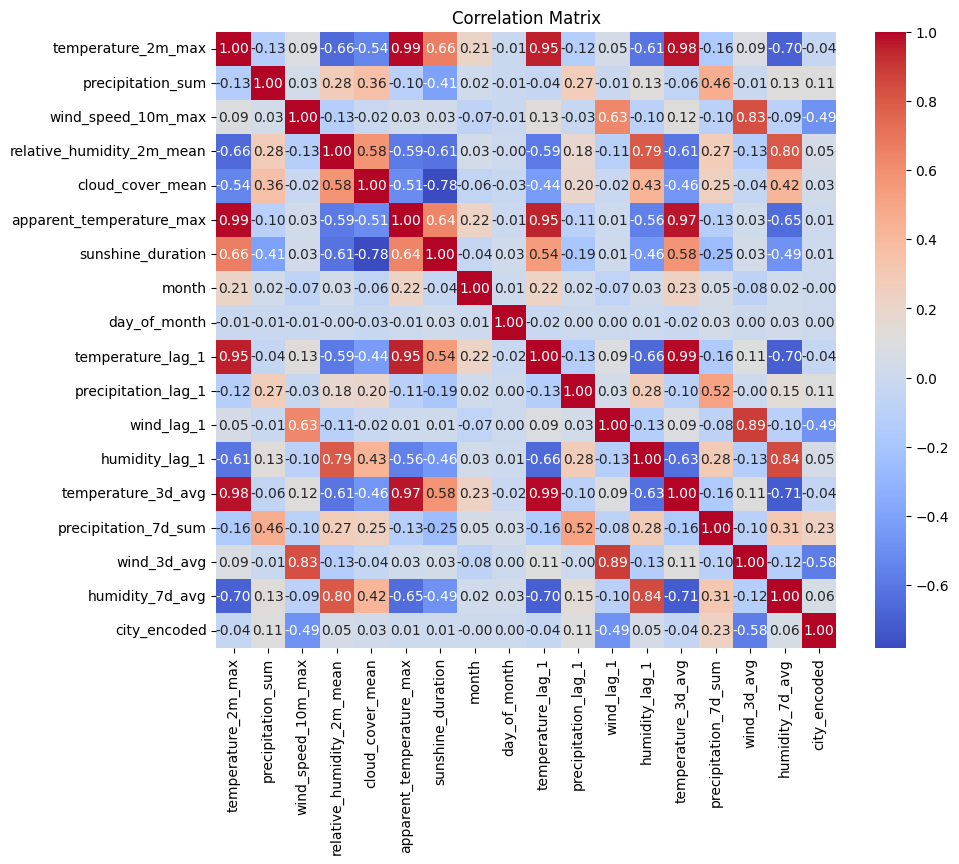

In [28]:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Hypothesis testing section

### Hypothesis 1: Temperature differs across cities

Good for tourism because cities have different climates.

H₀: Mean maximum temperature is the same across cities.  
H₁: At least one city has a different mean maximum temperature.  
Test: One-way ANOVA.

In [37]:
from scipy.stats import f_oneway

groups = [
    group["temperature_2m_max"].dropna()
    for city, group in df.groupby("city")
]

stat, p = f_oneway(*groups)

print("ANOVA statistic:", stat)
print("p-value:", p)

ANOVA statistic: 96.62919306663787
p-value: 6.161615664486518e-81


If p-value < 0.05, we reject the null hypothesis. 
This means average maximum temperature is significantly different across at least one city.
This supports treating city as an important feature in the prediction model.

## Hypothesis 2: Rainfall differs between coastal and mountain/region cities
Example: Baku vs Lankaran or Gabala.

H₀: Mean precipitation is the same in both cities.
H₁: Mean precipitation is different.
Test: Mann-Whitney U test, because precipitation is usually not normally distributed.

In [49]:
df['city'].unique()

array(['Baku', 'Gabala', 'Guba', 'Lankaran', 'Shaki'], dtype=object)

In [65]:
from scipy.stats import mannwhitneyu

city_a = df_may_june[df_may_june["city"] == "Baku"]["precipitation_sum"].dropna()
city_b = df_may_june[df_may_june["city"] == "Guba"]["precipitation_sum"].dropna()

stat, p = mannwhitneyu(city_a, city_b, alternative="two-sided")

print("Mann-Whitney U statistic:", stat)
print("p-value:", p.round(8))

Mann-Whitney U statistic: 51488.5
p-value: 0.0


If p-value < 0.05, we conclude that precipitation patterns are significantly different between the two cities.
This is important because rainfall directly affects outdoor tourism activities.

## Hypothesis 3: Wind speed differs across cities
Useful because Baku may be windier.

H₀: Wind speed distribution is the same across selected cities.
H₁: Wind speed differs across cities.
Test: Kruskal-Wallis test.

In [45]:
from scipy.stats import kruskal

groups = [
    group["wind_speed_10m_max"].dropna()
    for city, group in df.groupby("city")
]

stat, p = kruskal(*groups)

print("Kruskal-Wallis statistic:", stat)
print("p-value:", p)

Kruskal-Wallis statistic: 3081.746141488388
p-value: 0.0
